# Setup

In [1]:
# %load_ext autoreload
# %autoreload 2

In [12]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Data

In [123]:
version = "2026-05-13-13h"
df_filepath = f"/gpfs01/berens/data/data/Eyewire2/manuscript/df_all_neurons_{version}.pickle"
df = pd.read_pickle(df_filepath)

print(df.shape)

(59003, 400)


In [46]:
def get_cellkind(row):
    cellclass = row['cellclass_final']
    celltype = row['celltype_final']
    soma_z = row['soma_z_um']

    if pd.isna(cellclass) or cellclass in ['BC', 'RGC']:
        return cellclass
    elif cellclass in ['AC']:
        if not pd.isna(celltype) and celltype in ['ON SAC', 'OFF SAC']:
            return celltype
        elif soma_z < 0:
            return 'dAC'
        else:
            return 'AC'

In [47]:
df['cellkind'] = df.apply(lambda x: get_cellkind(x), axis=1)

# Figures

In [15]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [16]:
version

fig_dir = f'../figures/All/v{version}'
os.makedirs(fig_dir, exist_ok=True)

In [17]:
from eyewire2_morphological_clustering.utils.colors import cellclass2color

## Z-Dens

In [18]:
df.rename({"perc_z_095_1": "perc_z_095", "perc_z_005_1": "perc_z_005"}, axis=1, inplace=True)

RGC
AC
BC


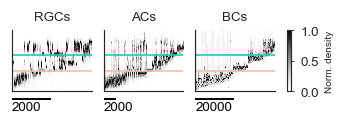

In [28]:
cellclasses = ['RGC', 'AC', 'BC']

fig, axs = plt.subplots(2, 4, figsize=(3, 0.8), sharex='col', height_ratios=(10, 1),
                        width_ratios=(1, 1, 1, 0.05))

for i, cellclass in enumerate(cellclasses):
    include = (df['cellclass_final'] == cellclass) & df['valid_cellclass_final']
    
    zi0 = 10
    zi1 = 100
    z0 = -20 + zi0*0.5
    z1 = -20 + zi1*0.5
    
    z_profiles_norm = np.vstack(df.loc[include, 'z_dens_1'])
    z_profiles_norm = z_profiles_norm[:, zi0:zi1]
    z_profiles_norm = (z_profiles_norm.T / (np.max(z_profiles_norm, axis=1) + 1e-20).T).T

    order = np.argsort(df.loc[include, "perc_z_005"])

    ax = axs[0, i]
    ax.set_title(cellclass + 's', fontsize=8)
    ax.set(xticks=[], yticks=[])
    im = ax.imshow(
        z_profiles_norm[order].T, aspect='auto', interpolation='none', origin='lower',
        extent=(0, z_profiles_norm.shape[0], z0, z1), rasterized=True, cmap='Grays')
    
    ax.axhline(0, ls='-', c=cellclass2color['ON SAC'], lw=1)
    ax.axhline(12, ls='-', c=cellclass2color['OFF SAC'], lw=1)

    ax = axs[1, i]
    ax.axis('off')

    if cellclass == 'BC':
        size = 20_000
    else:
        size = 2000
        
    ax.plot([0, size], [0.9, 0.9], c='k', solid_capstyle='butt')
    ax.text(0, 0.5, f'{size}', c='k', ha='left', va='top', fontsize=8)
    ax.set_ylim(0, 1)

cbar = plt.colorbar(im, ax=axs[0, -2], cax=axs[0, -1])
cbar.set_label('Norm. density', fontsize=6)
cbar.outline.set_visible(True)
axs[1, -1].axis('off')

fig.savefig(f'{fig_dir}/cellclass-z-profiles.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/cellclass-z-profiles.png', dpi=600, bbox_inches='tight')

# TSNE

In [31]:
emb_cols_norm = [c for c in df.columns if c.startswith('ALLemb_norm')]
emb_cols_norm

['ALLemb_norm-r-PC0',
 'ALLemb_norm-r-PC1',
 'ALLemb_norm-r-PC2',
 'ALLemb_norm-r-PC3',
 'ALLemb_norm-t-PC0',
 'ALLemb_norm-t-PC1',
 'ALLemb_norm-z-PC0',
 'ALLemb_norm-z-PC1',
 'ALLemb_norm-z-PC2',
 'ALLemb_norm-z-PC3',
 'ALLemb_norm-z-PC4',
 'ALLemb_norm-z-PC5',
 'ALLemb_norm-z-PC6',
 'ALLemb_norm-z-PC7',
 'ALLemb_norm-z-PC8',
 'ALLemb_norm-z-PC9',
 'ALLemb_norm-res(rt)-PC0',
 'ALLemb_norm-res(rz)-PC0',
 'ALLemb_norm-res(tz)-PC0',
 'ALLemb_norm-soma_z_um',
 'ALLemb_norm-log_xys_dens_mean',
 'ALLemb_norm-log_hull_diameter',
 'ALLemb_norm-log_hull_perimeter',
 'ALLemb_norm-log_tips',
 'ALLemb_norm-log_branch_points',
 'ALLemb_norm-log_median_intermediate_segment_pl',
 'ALLemb_norm-log_median_terminal_segment_pl',
 'ALLemb_norm-log_tortuosity_median',
 'ALLemb_norm-branch_angle_median',
 'ALLemb_norm-branch_angle_mean',
 'ALLemb_norm-branch_angle_std',
 'ALLemb_norm-branch_angle_q5',
 'ALLemb_norm-branch_angle_q95',
 'ALLemb_norm-path_angle_median',
 'ALLemb_norm-path_angle_mean',
 'ALLe

## Compute

In [32]:
df['include_in_embedding'] = (df["fda_weight"] > 0) & df["valid_cellclass_final"]

In [33]:
import scanpy as sc

adata = sc.AnnData(df.loc[df['include_in_embedding'], emb_cols_norm].values)
sc.tl.tsne(adata, perplexity=30, use_rep='X')  # 20?

In [34]:
df['tsne_d0'] = np.nan
df['tsne_d1'] = np.nan

df.loc[df["include_in_embedding"], 'tsne_d0'] = adata.obsm["X_tsne"][:, 0]
df.loc[df["include_in_embedding"], 'tsne_d1'] = adata.obsm["X_tsne"][:, 1]

## TSNE - plot

In [36]:
cellkinds = [
    'RGC',
    'AC',
    'dAC',
    'ON SAC',
    'OFF SAC',
    'BC',
]

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


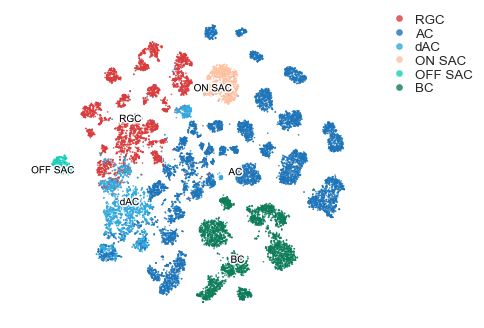

In [48]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

plot_embedding_v2(
    df=df[df['include_in_embedding']],
    label2color=cellclass2color,
    fig_path_prefix=f"{fig_dir}/class-tsne",
    celltype_col='cellkind',
    plot_order=cellkinds,
    is_labelled_col="valid_cellclass_final",
    dot_size=1,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=4,
    figsize=(4, 3.3)
)

/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/embedding.py:229: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


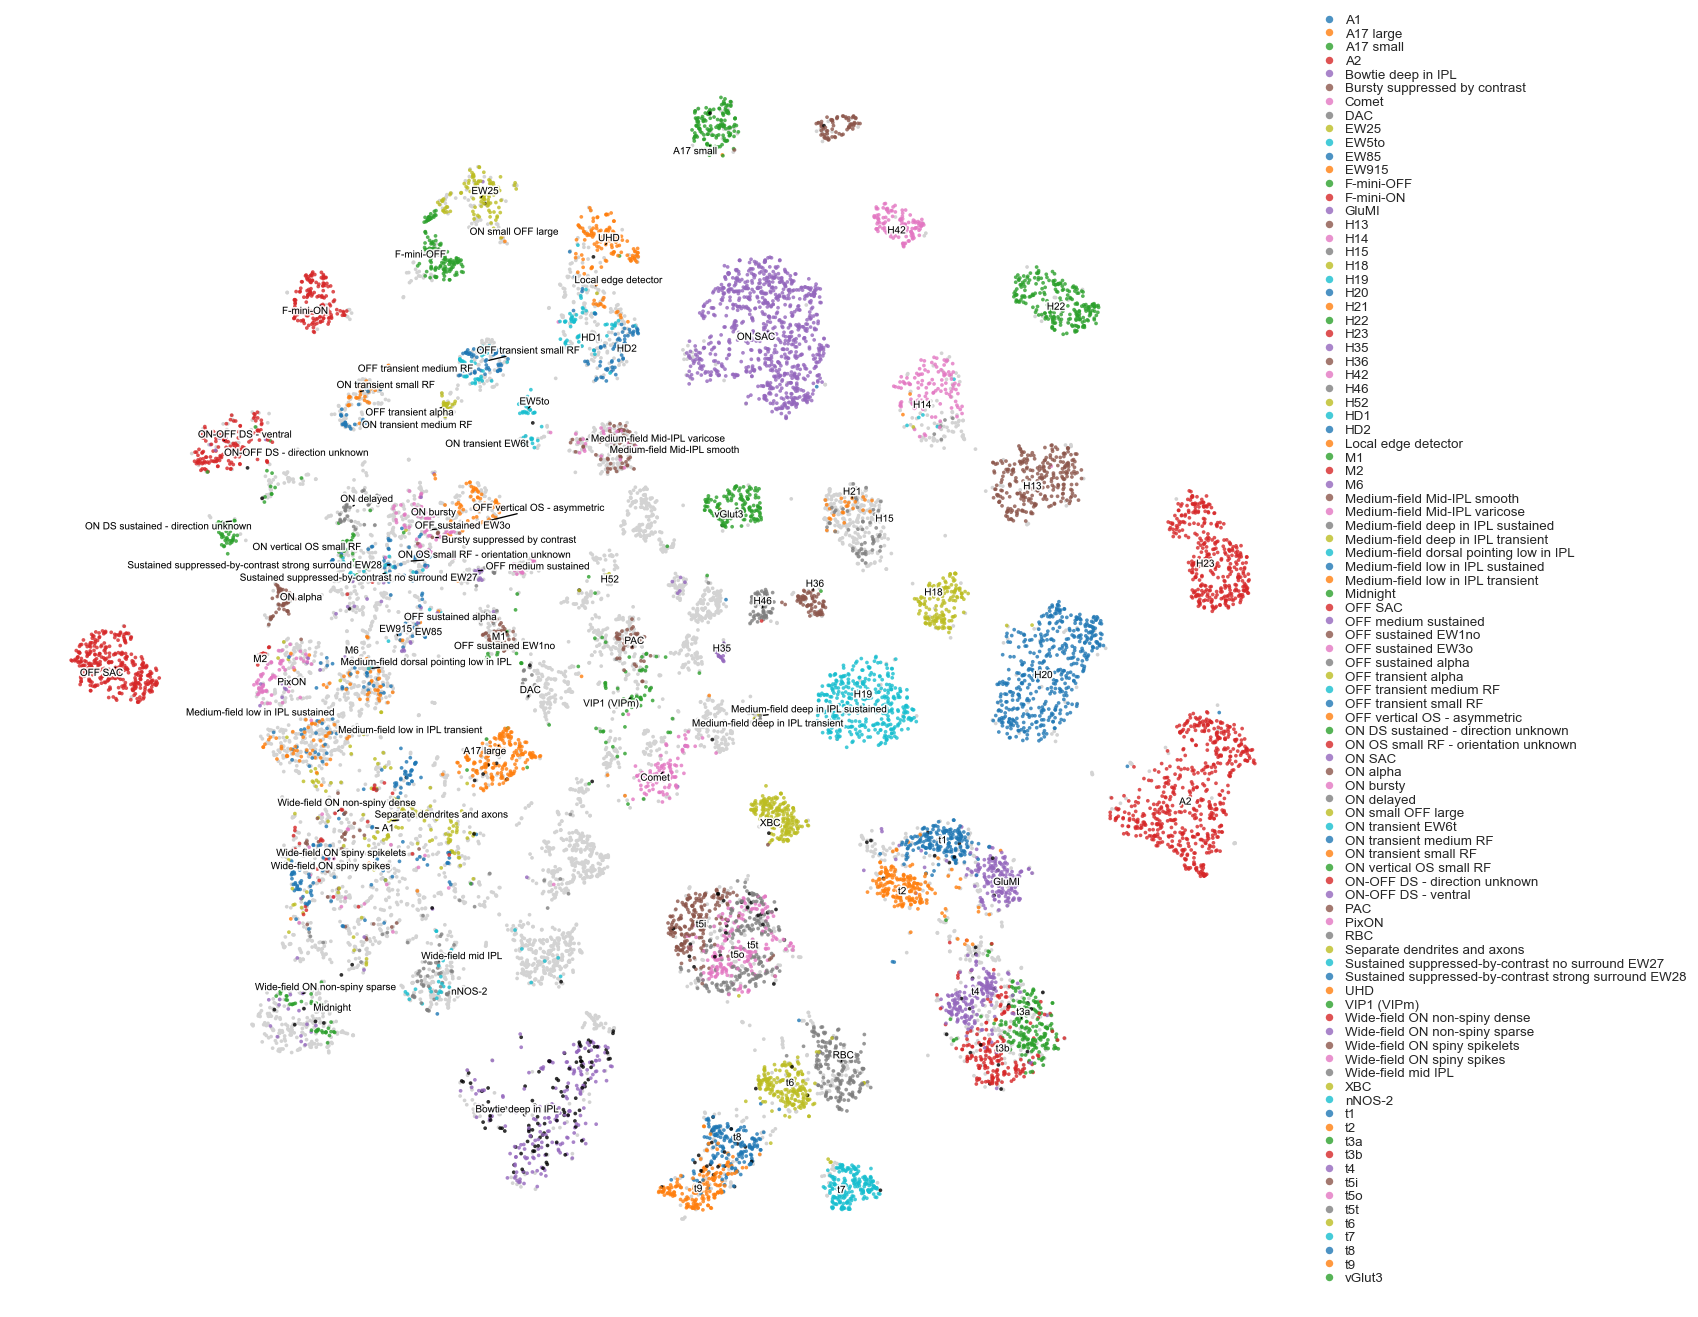

In [57]:
from eyewire2_morphological_clustering.utils.embedding import plot_embedding_v2

type_order = np.unique(df.loc[df['include_in_embedding'] & df['valid_celltype_final'], 'celltype_final'])

plot_embedding_v2(
    df=df[df['include_in_embedding']],
    label2color={k: f'C{i}' for i, k in enumerate(type_order)},
    fig_path_prefix=f"{fig_dir}/class-tsne-celltype-for-ref",
    celltype_col='celltype',
    plot_order=type_order,
    is_labelled_col="valid_celltype_final",
    dot_size=5,
    edgecolor="none",
    rasterized=True,
    legend_markerscale=2,
    figsize=(14, 14)
)

In [51]:
example_feature_names = [
    'perc_z_005',
    'perc_z_095',
    'log_radius_median',
    'log_tips',
    'log_hull_diameter',
]

example_features = df.loc[:, example_feature_names].values

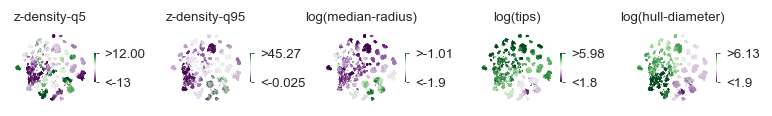

In [52]:
from eyewire2_morphological_clustering.utils.embedding import save_and_plot_feats

fig, axs = save_and_plot_feats(
    all_emb=df.loc[:, ['tsne_d0', 'tsne_d1']].values,
    all_feats=example_features,
    all_feat_names=example_feature_names, 
    ncols=5,
    clip=False,
    stride=1, 
    figsize_per_cell=(1.3, 1)
)

plt.tight_layout(h_pad=0.3)

fig.savefig(f'{fig_dir}/class-tnse-features.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/class-tnse-features.png', dpi=600, bbox_inches='tight')

## Examples

In [66]:
from eyewire2_morphological_clustering.utils.plot_cells import plot_rows


def plot_examples(name, rows, color, df, ):
    
    rad = np.maximum(20, (rows.hull_diameter.max() / 2) * 1.3)

    size = 1.8 * rad

    if size >= 1000:
        size = int(size // 1000) * 1000
    elif size >= 600:
        size = int(size // 200) * 200
    elif size >= 200:
        size = int(size // 100) * 100
    else:
        size = int(size // 50) * 50

    if size <= 20:
        size = 20
    
    fig, axs = plt.subplots(
        2, len(rows), figsize=(0.7*(len(rows)), 1.5), squeeze=False,
        height_ratios=(2.5, 3),
        subplot_kw=dict(xlabel=None, ylabel=None, xticks=[], yticks=[]))
    fig.subplots_adjust(wspace=0, hspace=0)
    
    for ax in axs.flat:
        ax.axis('off')
        
    print(rows.index.astype(int))
    fig, fig2 = plot_rows(
        rows=rows,
        rad=rad,
        size=size,
        fig=fig,
        axs=axs,
        color=color,
        sb_fontsize=8,
        show_on_tsne=True,
        df=df,
        is_labelled=df['include_in_embedding'],
        labels=df['cellkind'],
        label_order=cellkinds,
        celltype2color=cellclass2color,
        
    )

    axs[0, 1].set_title(celltype, fontsize=8)

    fig.savefig(f'{fig_dir}/celltype-example_{name}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/celltype-example_{name}.png', dpi=600, bbox_inches='tight')
    
    fig2.savefig(f'{fig_dir}/celltype-example_{name}_on_tsne.png', dpi=200, bbox_inches='tight')
    
    plt.show()

In [86]:
prefer_label = df['include_in_embedding'] & df['valid_celltype_final'] & (df.celltype_final_decision == 'both_strong')

Index([720575940537038003, 720575940537340595, 720575940541316472], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


14.3 63.3
12.4 60.7
16.9 72.3


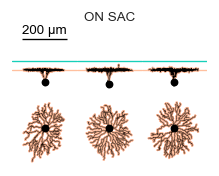

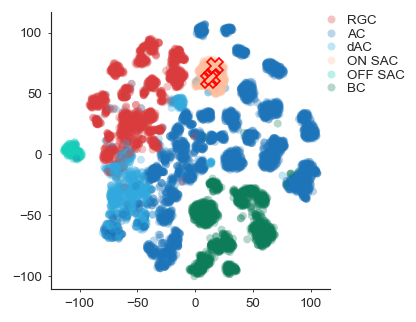

In [122]:
#[720575940537340595, 720575940537038003, 720575940547708345]
celltype = 'ON SAC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 8]]
plot_examples(celltype, rows, color=cellclass2color[celltype], df=df)

Index([720575940547977603, 720575940545977605, 720575940546515205], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-101.3 -1.0
-100.4 1.9
-103.9 2.2


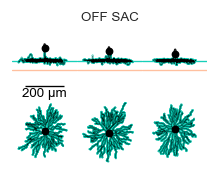

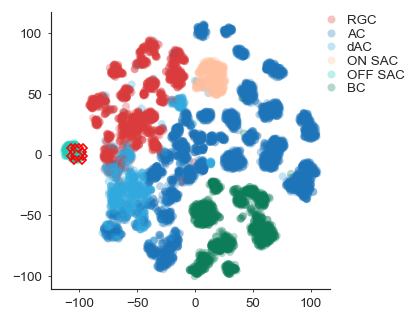

In [92]:
#[720575940546515205, 720575940545977605, 720575940552020693]
celltype = 'OFF SAC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[5, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color[celltype], df=df)

Index([720575940545459029, 720575940545853013, 720575940550115936], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


12.9 -24.6
16.0 -23.9
14.2 -23.0


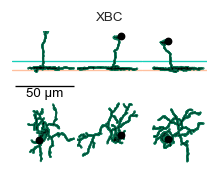

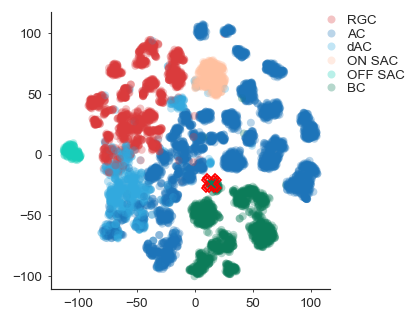

In [118]:
#[720575940546300812, 720575940550297826, 720575940550977354]
celltype = 'XBC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 4]]
plot_examples(celltype, rows, color=cellclass2color['BC'], df=df)

Index([720575940545977659, 720575940547248354, 720575940548109187], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


35.0 -93.4
29.1 -96.5
30.3 -97.1


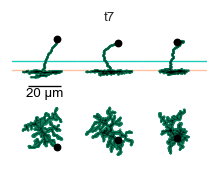

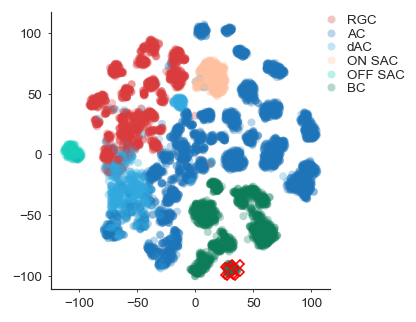

In [98]:
#[720575940546124347, 720575940549473063, 720575940551549694]
celltype = 't7'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['BC'], df=df)

Index([720575940545083106, 720575940546845113, 720575940547198528], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


28.6 -76.3
28.8 -77.9
28.2 -76.3


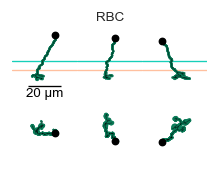

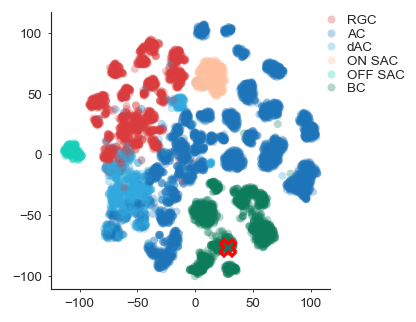

In [99]:
#[720575940548828475, 720575940549329703, 720575940550964607]
celltype = 'RBC'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['BC'], df=df)

Index([720575940545021781, 720575940548829000, 720575940546771129], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


37.8 -36.6
42.0 -37.1
39.1 -38.8


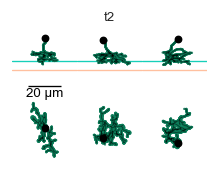

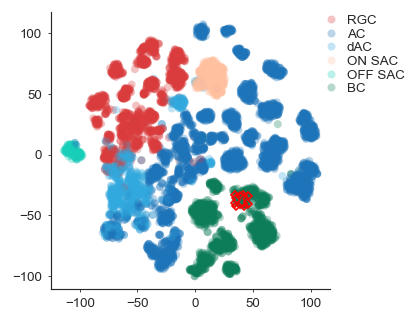

In [120]:
#[720575940542708061, 720575940550981271, 720575940552870736]
celltype = 't2'
rows = df.loc[(df.celltype_final == celltype) & prefer_label & prefer_bcs].iloc[[0, 4, 3]]
plot_examples(celltype, rows, color=cellclass2color['BC'], df=df)

Index([720575940537745467, 720575940545483763, 720575940540977784], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


100.9 -21.3
91.8 -8.9
100.4 -13.3


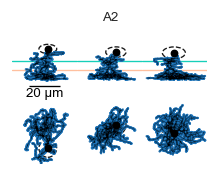

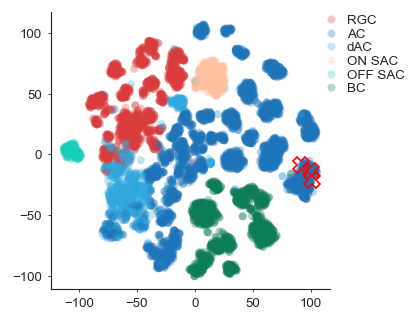

In [102]:
#[720575940537745467, 720575940550665306, 720575940553404823]
celltype = 'A2'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 3, 2]]
plot_examples(celltype, rows, color=cellclass2color['AC'], df=df)

Index([720575940537111219, 720575940540887928, 720575940540929656], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


72.6 66.3
61.4 73.4
72.4 64.4


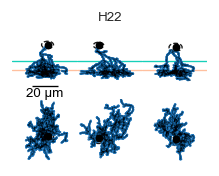

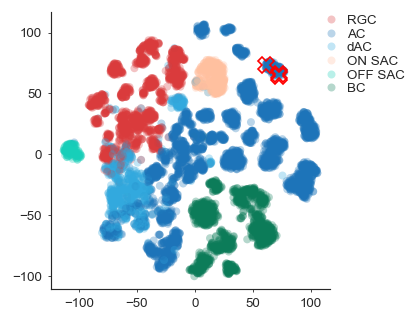

In [103]:
#[720575940537111219, 720575940551299904, 720575940552392899]
celltype = 'H22'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['AC'], df=df)

Index([720575940537001651, 720575940537190067, 720575940545518677], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


95.6 14.5
102.3 16.4
91.6 32.2


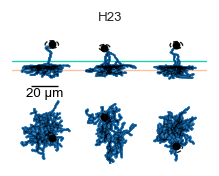

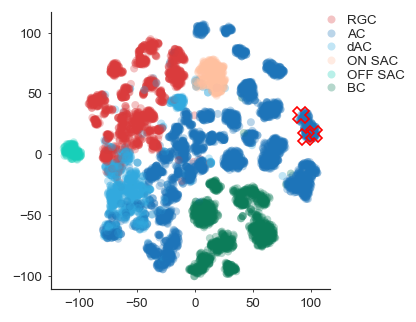

In [104]:
#[720575940550450006, 720575940552869722, 720575940555335127]
celltype = 'H23'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['AC'], df=df)

Index([720575940540958584, 720575940546011891, 720575940546882821], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-33.7 -10.4
-38.6 -17.3
-28.5 -14.4


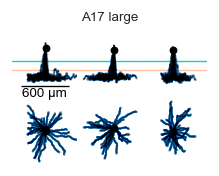

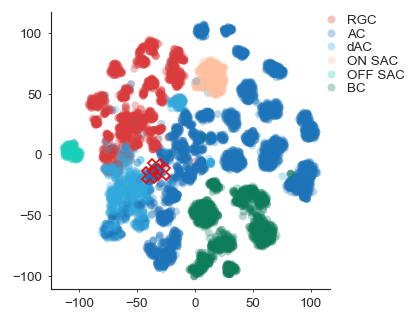

In [105]:
#[720575940540987000, 720575940548065736, 720575940551946226]
celltype = 'A17 large'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['AC'], df=df)

Index([720575940547396281, 720575940549376315, 720575940549861346], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


9.9 101.3
8.5 101.0
7.0 102.8


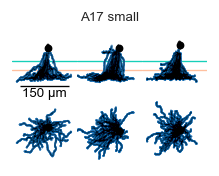

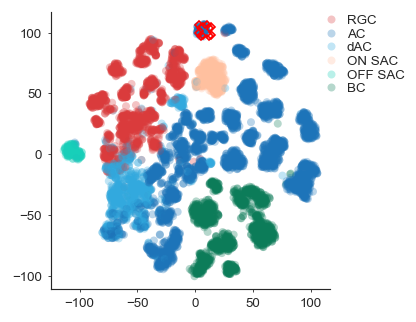

In [106]:
#[720575940549861346, 720575940554716380, 720575940562383535]
celltype = 'A17 small'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['AC'], df=df)

Index([720575940537569971, 720575940541163128, 720575940545348339], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-70.6 65.7
-69.1 71.1
-63.9 68.1


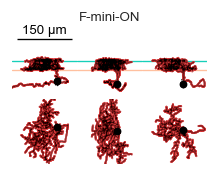

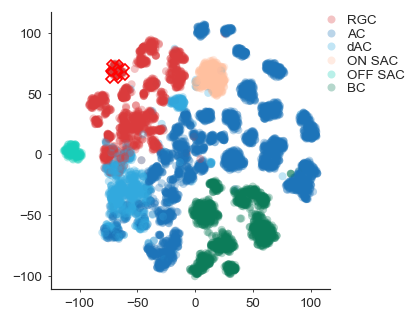

In [107]:
#[720575940537569971, 720575940545506547, 720575940549663970]
celltype = 'F-mini-ON'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['RGC'], df=df)

Index([720575940537434291, 720575940537466547, 720575940540777592], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-47.0 79.5
-47.3 74.2
-44.8 77.7


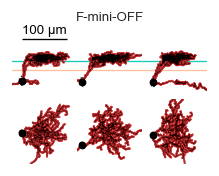

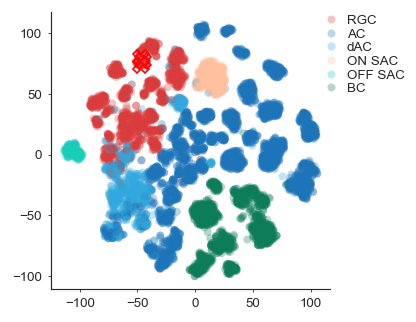

In [108]:
#[720575940537341619, 720575940551167200, 720575940553973923]
celltype = 'F-mini-OFF'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['RGC'], df=df)

Index([720575940550427362, 720575940553553059, 720575940553722711], dtype='int64', name='cell')


/gpfs01/berens/user/joesterle/github/eulerlab/eyewire2-morphological-clustering/eyewire2_morphological_clustering/utils/plot_cells.py:632: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hue=labels[rand_order],


-43.8 50.9
-44.4 50.8
-44.3 49.6


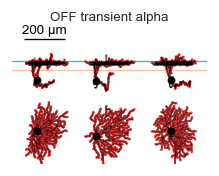

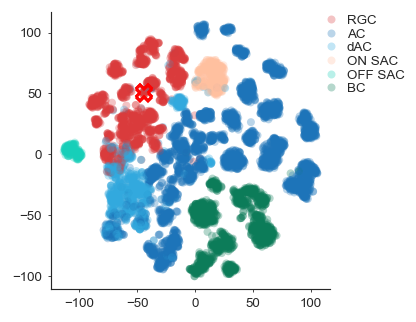

In [109]:
#[720575940550012386, 720575940553722711, 720575940556741760]
celltype = 'OFF transient alpha'
rows = df.loc[(df.celltype_final == celltype) & prefer_label].iloc[[0, 1, 2]]
plot_examples(celltype, rows, color=cellclass2color['RGC'], df=df)

## Mosaics

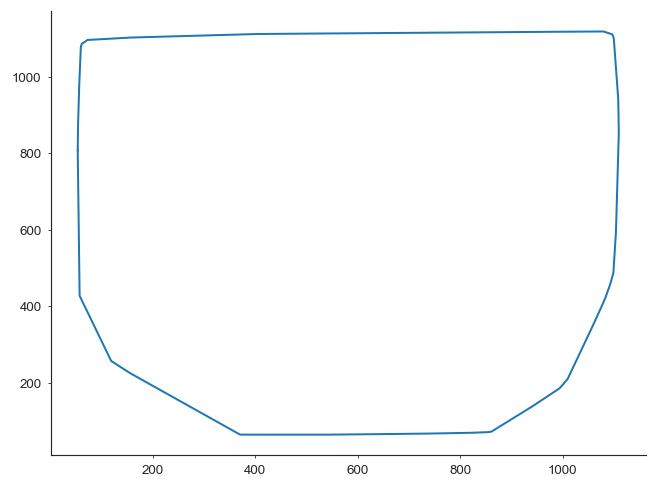

In [110]:
from scipy.spatial import ConvexHull

pts = np.vstack(df.hull_points)[:, :2]
hull = ConvexHull(pts)

# Get hull boundary points in order, closed
hull_pts = pts[np.append(hull.vertices, hull.vertices[0])]
plt.plot(*hull_pts.T)
plt.show()

In [111]:
from eyewire2_morphological_clustering.utils.mosaics import polygon_centroid

df['hull_center'] = df.hull_points.apply(polygon_centroid)
df['hull_center_x'] = df['hull_center'].apply(lambda x: x[0])
df['hull_center_y'] = df['hull_center'].apply(lambda x: x[1])

celltype='F-mini-ON': Found 160 cells and 72 candidates.
celltype='A2': Found 555 cells and 362 candidates.
celltype='H22': Found 233 cells and 120 candidates.
celltype='H23': Found 364 cells and 175 candidates.
celltype='ON SAC': Found 852 cells and 191 candidates.
celltype='OFF SAC': Found 337 cells and 53 candidates.
celltype='A17 large': Found 181 cells and 91 candidates.
celltype='A17 small': Found 156 cells and 53 candidates.
celltype='XBC': Found 671 cells and 10 candidates.
celltype='t7': Found 2218 cells and 40 candidates.


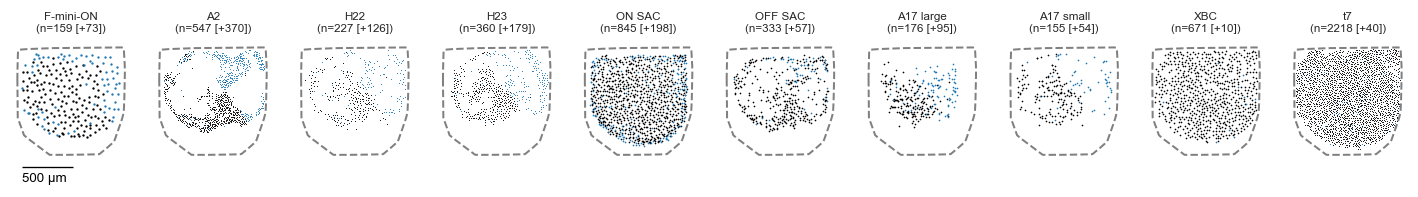

In [121]:
from eyewire2_morphological_clustering.utils.mosaics import plot_multiple_mosaics

max_val = 7

celltypes = ['F-mini-ON', 'A2', 'H22', 'H23', 'ON SAC', 'OFF SAC', 'A17 large', 'A17 small', 'XBC', 't7']
marker_sizes = [2, 0.3, 0.3, 0.3, 1, 1, 1, 1, 1, 0.3]
ncols = len(celltypes)

for name, extent in {'wide': [50, 1150, 50, 1150]}.items(): # 'zoom2': [200, 300, 600, 700], 'zoom': [200, 400, 600, 800]
    
    fig, axs = plt.subplots(ncols=len(celltypes), nrows=1, figsize=(len(celltypes)*1.5, 2),
                            sharex='row', sharey='row', squeeze=False)    
    if 'wide' in name.lower():
        sns.despine(top=True, right=True, left=True, bottom=True)
    else:
        sns.despine(top=False, right=False, left=False, bottom=False)
    
    ims, c_maxs = plot_multiple_mosaics(
        df=df[df.valid_celltype_final],
        celltype_col='celltype',
        candidate_col='celltype_final',
        candidate_color='C0',
        celltypes=celltypes,
        fig=fig,
        coverage_axs=None,
        resolutions=[1000] * ncols,
        center_axs=axs[0, :],            
        title_axs=axs[0, :],
        sb_axs=[axs[0, 0]],
        center_x_col="hull_center_x",
        center_y_col="hull_center_y",
        marker_sizes=marker_sizes,
        max_val=max_val,
        extent=extent,
        plot_outlines='zoom' in name.lower(),
        outline_hull=hull_pts if 'wide' in name.lower() else None,
        cb=False,
        sb_size=500 if 'wide' in name.lower() else 100,
    )

    for j, ax in enumerate(axs.flat):
        celltype = celltypes[j]
        df_ct = df[(df.celltype_final==celltype) & df.valid_celltype_final]
        n_cells = len(df_ct)
        n_cells_clf = sum(df_ct.celltype_final_decision == 'classifier')
        n_cells_label = n_cells - n_cells_clf
        if n_cells_clf > 0:
            ax.set_title(f"{celltype}\n(n={n_cells_label} [+{n_cells_clf}])", fontsize=7)
        else:
            ax.set_title(f"{celltype}\n(n={n_cells_label})", fontsize=7)
    
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.svg', dpi=600, bbox_inches='tight')
    fig.savefig(f'{fig_dir}/scatter-class_{extent}.png', dpi=600, bbox_inches='tight')
    plt.show()

# Copy all figures

In [107]:
import shutil

shutil.copytree(fig_dir, f"/gpfs01/euler/data/Resources/Eyewire2/figures/{fig_dir}", dirs_exist_ok=True)

'/gpfs01/euler/data/Resources/Eyewire2/figures/figures/class_2026-03-16-16h'